In [1]:
import snntorch as snn
from snntorch import spikeplot as splt
from snntorch import spikegen

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import itertools

In [2]:
class LeakySurrogate(nn.Module):
    def __init__(self, beta, threshold=1.0):
        super(LeakySurrogate, self).__init__()

        self.beta = beta
        self.threshold = threshold
        self.spike_gradient = self.ATan.apply

    # Called each time Leaky is called
    def forward(self, input_, mem):
        spk = self.spike_gradient((mem - self.threshold))
        reset = (self.beta * spk * self.threshold).detach()
        mem = self.beta * mem + input_ - reset
        return spk, mem

    # Forward pass: Heaviside function
    # Backward pass: Override Dirac Delta with the derivative of the ArcTan function (surrogate gradients)
    @staticmethod
    class ATan(torch.autograd.Function):
        @staticmethod
        def forward(ctx, mem):
            spk = (mem > 0).float()
            ctx.save_for_backward(mem)
            return spk

        @staticmethod
        def backward(ctx, grad_output):
            (mem,) = ctx.saved_tensors
            grad = 1 / (1 + (np.pi * mem).pow_(2)) * grad_output
            return grad

In [3]:
lif1 = LeakySurrogate(beta=0.9)

In [2]:
batch_size = 128
data_path = '/tmp/data/mnist'

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [3]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

In [4]:
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

In [5]:
num_inputs = 28 * 28
num_hidden = 1000
num_outputs = 10

num_steps = 25
beta = 0.95

In [11]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            print(type(cur1))
            print(cur1.shape)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

net = Net().to(device)

In [7]:
# Very useful for me for training and accuracy evaluation!!
def print_batch_accuracy(data, targets, train=False):
    output, _ = net(data.view(batch_size, -1))
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer():
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

In [8]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

In [12]:
data, targets = next(iter(train_loader))
data = data.to(device)
targets = targets.to(device)

spk_rec, mem_rec = net(data.view(batch_size, -1))
print(mem_rec.size())

<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch.Tensor'>
torch.Size([128, 1000])
<class 'torch

In [10]:
loss_val = torch.zeros((1), dtype=dtype, device=device)
for step in range(num_steps):
    loss_val += loss(mem_rec[step], targets)

print(f"Training loss: {loss_val.item():.3f}")
print_batch_accuracy(data, targets, train=True)

Training loss: 59.553
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
Train set accuracy for a single minibatch: 13.28%


In [18]:
optimizer.zero_grad()
loss_val.backward()
optimizer.step()

spk_rec, mem_rec = net(data.view(batch_size, -1))
loss_val = torch.zeros((1), dtype=dtype, device=device)
for step in range(num_steps):
    loss_val += loss(mem_rec[step], targets)

print(f"Training loss: {loss_val.item():.3f}")
print_batch_accuracy(data, targets, train=True)

Training loss: 42.547
Train set accuracy for a single minibatch: 81.25%


In [19]:
num_epochs = 1
loss_hist = []
test_loss_hist = []
counter = 0

for epoch in range(num_epochs):
    iter_counter = 0
    train_batch = iter(train_loader)

    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)

        net.train()
        spk_rec, mem_rec = net(data.view(batch_size, -1))

        loss_val = torch.zeros((1), dtype=dtype, device=device)
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        loss_hist.append(loss_val.item())

        with torch.no_grad():
            net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)

            test_spk, test_mem = net(test_data.view(batch_size, -1))
            test_loss = torch.zeros((1), dtype=dtype, device=device)
            for step in range(num_steps):
                test_loss += loss(test_mem[step], test_targets)
            test_loss_hist.append(test_loss.item())

            if counter % 50 == 0:
                train_printer()
            counter += 1
            iter_counter += 1

Epoch 0, Iteration 0
Train Set Loss: 47.67
Test Set Loss: 43.18
Train set accuracy for a single minibatch: 63.28%
Test set accuracy for a single minibatch: 67.97%


Epoch 0, Iteration 50
Train Set Loss: 17.39
Test Set Loss: 17.86
Train set accuracy for a single minibatch: 78.91%
Test set accuracy for a single minibatch: 84.38%


Epoch 0, Iteration 100
Train Set Loss: 8.26
Test Set Loss: 11.62
Train set accuracy for a single minibatch: 94.53%
Test set accuracy for a single minibatch: 90.62%


Epoch 0, Iteration 150
Train Set Loss: 8.69
Test Set Loss: 9.96
Train set accuracy for a single minibatch: 91.41%
Test set accuracy for a single minibatch: 88.28%


Epoch 0, Iteration 200
Train Set Loss: 8.46
Test Set Loss: 12.29
Train set accuracy for a single minibatch: 91.41%
Test set accuracy for a single minibatch: 89.84%


Epoch 0, Iteration 250
Train Set Loss: 6.48
Test Set Loss: 9.49
Train set accuracy for a single minibatch: 95.31%
Test set accuracy for a single minibatch: 89.06%


Epoch 0

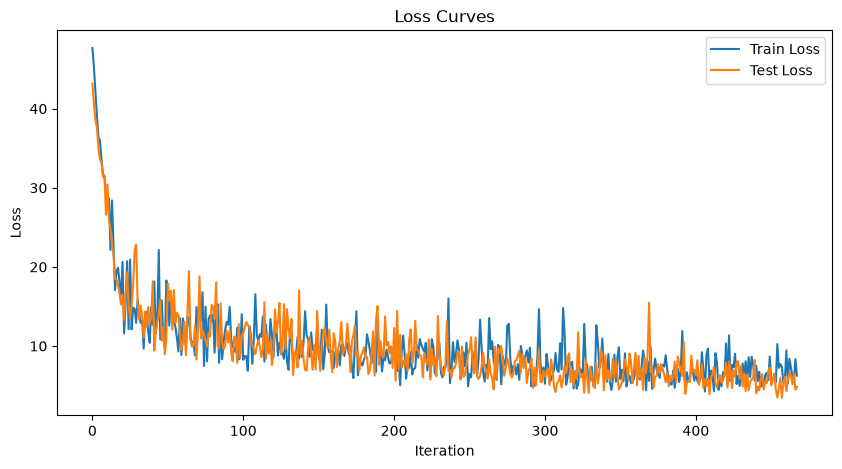

In [20]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss Curves")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [22]:
total = 0
correct = 0

test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

with torch.no_grad():
    net.eval()
    for data, targets in test_loader:
        data = data.to(device)
        targets = targets.to(device)

        test_spk, _ = net(data.view(data.size(0), -1))

        _, predicted = test_spk.sum(dim=0).max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

print(f"Total correctly classified test set images: {correct}/{total}")
print(f"Test Set Accuracy: {100 * correct / total:.2f}%")

Total correctly classified test set images: 9491/10000
Test Set Accuracy: 94.91%
